# Figures 

In [1]:
import tskit
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import glob
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.image as mpimg
import io
import cairosvg 

# Metadata

In [12]:
poporder = ['cor1','cor3','cor2',
            'hyb1',
            'cnx5','cnx1','cnx3','cnx2','cnx4','cnx6',
            ]
colormap = {
    'cor1': "#B22222", 'cor3': "#E31A1C", 'cor2': "#FF9999", 
    'hyb1': 'purple',     
    'cnx6': "#08306B", 'cnx4': "#08519C", 'cnx2': "#2171B5", 'cnx3':"#4292C6", 'cnx1':"#6BAED6", 'cnx5':"#C6DBEF"
}
markermap = {
    'cor1': '<', 'cor2': '>', 'cor3': 'o', 
    'hyb1': 'X',     
    'cnx1': 'o', 'cnx2': 's', 'cnx3': '^', 'cnx4': '>', 'cnx5': '<', 'cnx6': 'v'
}
labelmap = {
    'cor1': 'corone-spain', 'cor2': 'corone-germany', 'cor3': 'corone-france', 
    'hyb1': 'corone-cornix hybrid',     
    'cnx1': 'cornix-italy', 'cnx2': 'cornix-bulgaria/levant', 'cnx3': 'cornix-poland/sweden', 'cnx4': 'cornix-russia', 'cnx5': 'cornix-corsica', 'cnx6': 'cornix-iraq'
}

In [13]:
poplabels = []
with open('../data/poplabels_filtered.txt','r') as f:
    next(f)
    for line in f:
        poplabels.append(line.strip().split()[1])
pops, ixs = np.unique(poplabels,return_index=True)

In [14]:
chrs = []
with open('../data/chr_names.txt','r') as f:
    for line in f:
        chrs.append(line.strip())

In [15]:
chrmap =  {
           'chr1': 'NC_046332.1',
           'chr2': 'NC_046333.1',
           'chr3': 'NC_047056.1',
           'chr4': 'NC_046334.1',
           'chr5': 'NC_046335.1',
           'chr6': 'NC_046336.1',
           'chr7': 'NC_046337.1',
           'chr8': 'NC_046338.1',
           'chr9': 'NC_046339.1',
           'chr10': 'NC_046340.1',
           'chr11': 'NC_046341.1',
           'chr12': 'NC_046342.1',
           'chr13': 'NC_046343.1',
           'chr14': 'NC_046344.1',
           'chr15': 'NC_046345.1',
           'chr1A': 'NC_047057.1',
           'chr17': 'NC_046346.1',
           'chr18': 'NC_046347.1',
           'chr19': 'NC_046348.1',
           'chr20': 'NC_046349.1',
           'chr21': 'NC_046350.1',
           'chr22': 'NC_046351.1',
           'chr23': 'NC_046352.1',
           'chr24': 'NC_046353.1',
           'chr4A': 'NC_047058.1',
           'chr26': 'NC_046354.1',
           'chr27': 'NC_046355.1',
           'chr28': 'NC_046356.1'}

In [16]:
locations = np.load("../data/locations.npy") #from Tabris

sample_data = []
with open("../data/poplabels.txt",'r') as f:
    next(f)
    for line,loc in zip(f,locations.repeat(2,axis=0)):
        sample_data.append(line.strip().split(' ') + [float(i) for i in loc]) #merge sample names, pop, and locations together

dropped_samples = []
with open("../data/dropped_samples.txt",'r') as f:
    for line in f:
        dropped_samples.append(line.strip())

sample_data_filtered = [item for item in sample_data if not any(target in item[0] for target in dropped_samples)]

# Figure 1

## sample locations

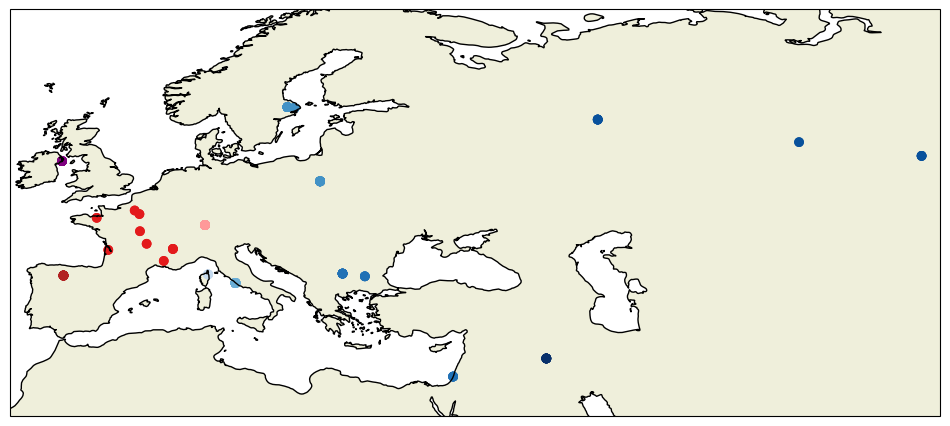

In [7]:
fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND)
ax.set_extent([-11, 85, 28, 70], crs=ccrs.PlateCarree())

ax.scatter([i[-2] for i in sample_data_filtered], [i[-1] for i in sample_data_filtered], color=[colormap[i[1]] for i in sample_data_filtered], alpha=1, transform=ccrs.PlateCarree())

plt.show()

## effective population sizes from Relate

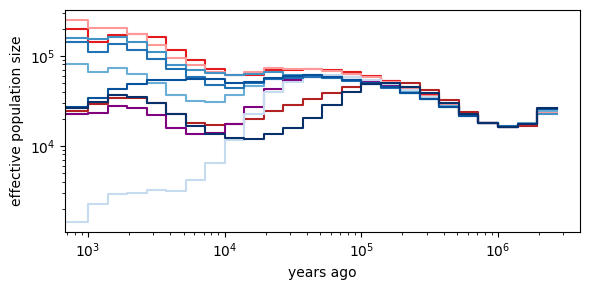

In [9]:
coal_files = sorted(glob.glob("../data/relate_*_popsize.pairwise.coal"))  # adjust pattern to match your files
years_per_gen = 5.79

def parse_coal(path):
    with open(path) as f:
        lines = f.readlines()
    group_names = lines[0].split()
    epoch_times = [float(x) for x in lines[1].split()]
    rows = {}
    for line in lines[2:]:
        parts = line.split()
        if not parts:
            continue
        i, j = int(parts[0]), int(parts[1])
        rates = [float(x) for x in parts[2:]]
        rows[(i, j)] = rates
    return group_names, epoch_times, rows

def count_trees(anc_path):
    with open(anc_path) as f:
        for line in f:
            if line.startswith("NUM_TREES"):
                return int(line.split()[1])
    raise ValueError(f"NUM_TREES not found in {anc_path}")

# Map each coal file to its corresponding .anc file to get tree counts
anc_files = [f.replace("pairwise.coal", "anc") for f in coal_files]  # adjust naming pattern
weights = np.array([count_trees(f) for f in anc_files], dtype=float)
weights /= weights.sum()

# print("Chromosome weights (fraction of total trees):")
# for f, w in zip(coal_files, weights):
#     print(f"  {f}: {w:.4f}")

all_parsed = [parse_coal(f) for f in coal_files]
group_names, epoch_times, _ = all_parsed[0]

plt.figure(figsize=(6, 3))

for pop in poporder:

    pop_idx = np.where(np.array(group_names)==pop)[0][0]
    
    rate_matrix = []
    for gn, et, rows in all_parsed:
        key = (pop_idx, pop_idx)
        rate_matrix.append(rows[key])

    rate_matrix = np.array(rate_matrix)  # shape: (n_chroms, n_epochs)

    # Weighted average across chromosomes, weighted by tree count
    weighted_rate = np.average(rate_matrix, axis=0, weights=weights)
    ne = [1 / (2 * r) if r > 0 else float("nan") for r in weighted_rate]
    times_years = [t * years_per_gen for t in epoch_times[:len(ne)]]

    plt.step(times_years, ne, where="post", label=labelmap[pop], color=colormap[pop])

plt.xscale("log")
plt.yscale("log")
plt.xlabel("years ago", fontsize=10)
plt.ylabel("effective population size", fontsize=10)
# plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

## branch-based PCA

### chr1

In [10]:
# chrname = 'NC_046332.1'
# ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
# pca = ts.pca(2, random_seed=1) #run pca with 2 axes
# np.save('../data/pca_%s.npy' %chrname, pca.factors)

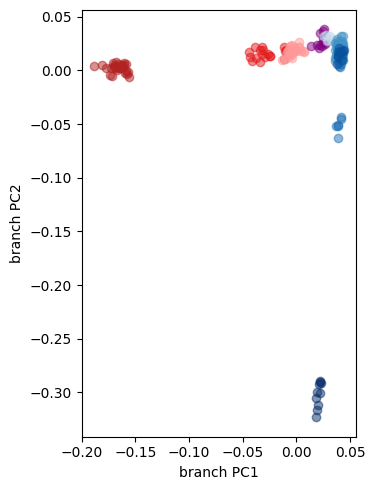

In [10]:
chrname = 'NC_046332.1'
pcafactors = np.load('../data/pca_%s.npy' %chrname)

fig = plt.figure(figsize=(5,5))

ax = plt.subplot()

for pop in poporder:
    data = pcafactors[np.where(np.array(poplabels)==pop)]
    # ax.scatter(-data[:,1], -data[:,0], color=colormap[pop], alpha=0.5, marker=markermap[pop], label=labelmap[pop])
    ax.scatter(data[:,0], data[:,1], color=colormap[pop], alpha=0.5, marker='o', label=labelmap[pop])

# plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
# plt.legend()
ax.set_xlabel('branch PC1', fontsize=10)
ax.set_ylabel('branch PC2', fontsize=10)
ax.set_aspect(1)

plt.tight_layout()
# plt.savefig('plots/pca_%s.png' %chrname)
plt.show()

### chr18

In [12]:
# chrname = 'NC_046347.1'
# ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
# pca = ts.pca(2, random_seed=1) #run pca with 2 axes
# np.save('../data/pca_%s.npy' %chrname, pca.factors)

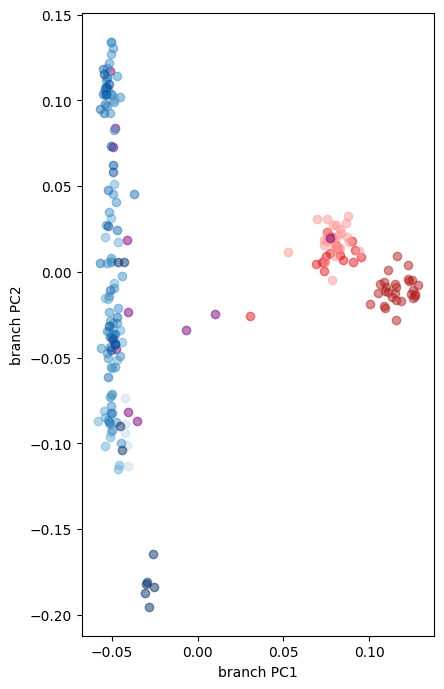

In [11]:
chrname = 'NC_046347.1'
pcafactors = np.load('../data/pca_%s.npy' %chrname)

fig = plt.figure(figsize=(7,7))

ax = plt.subplot()

for pop in poporder:
    data = pcafactors[np.where(np.array(poplabels)==pop)]
    # ax.scatter(-data[:,1], -data[:,0], color=colormap[pop], alpha=0.5, marker=markermap[pop], label=labelmap[pop])
    ax.scatter(-data[:,0], -data[:,1], color=colormap[pop], alpha=0.5, marker='o', label=labelmap[pop])

# plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
ax.set_xlabel('branch PC1', fontsize=10)
ax.set_ylabel('branch PC2', fontsize=10)
ax.set_aspect(1)

plt.tight_layout()
# plt.savefig('plots/pca_%s.png' %chrname)
plt.show()

## FST

In [12]:
# 
fst = []
windows = []
for c in chrmap.keys():
    fst.append(np.load('../data/fst_%s.npy' %chrmap[c]))
    windows.append(np.load('../data/fst_windows_%s.npy' %chrmap[c]))

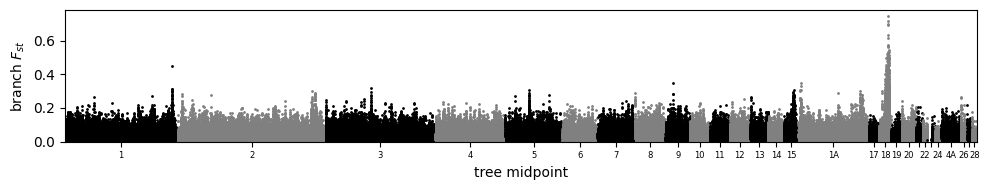

In [13]:
def colors(i):
    if i%2 == 0:
        return 'k'
    else:
        return 'gray'

fig = plt.figure(figsize=(10,2))
ax = plt.axes()

end = 0
xticks = []
for i,[b,f] in enumerate(zip(windows,fst)):
    ax.scatter([end+i for i in b[:-1]],f,color=colors(i),s=1)
    xticks.append(end + b[-1]/2)
    end += b[-1]
    
# plt.plot([0,end],[0.2,0.2],'--k')
ax.set_xlim(0,end)
ax.set_ylim(0,None)
ticks = ['' if c[3:] in {'21','23','27'} else c[3:] for c in chrmap.keys()]
ax.set_xticks(xticks, ticks, fontsize=6)
ax.set_ylabel(r'branch $F_{st}$', fontsize=10)
ax.set_xlabel('tree midpoint', fontsize=10)

plt.tight_layout()
# plt.savefig('plots/fst_corone-cornix.png')
plt.show()

## all together

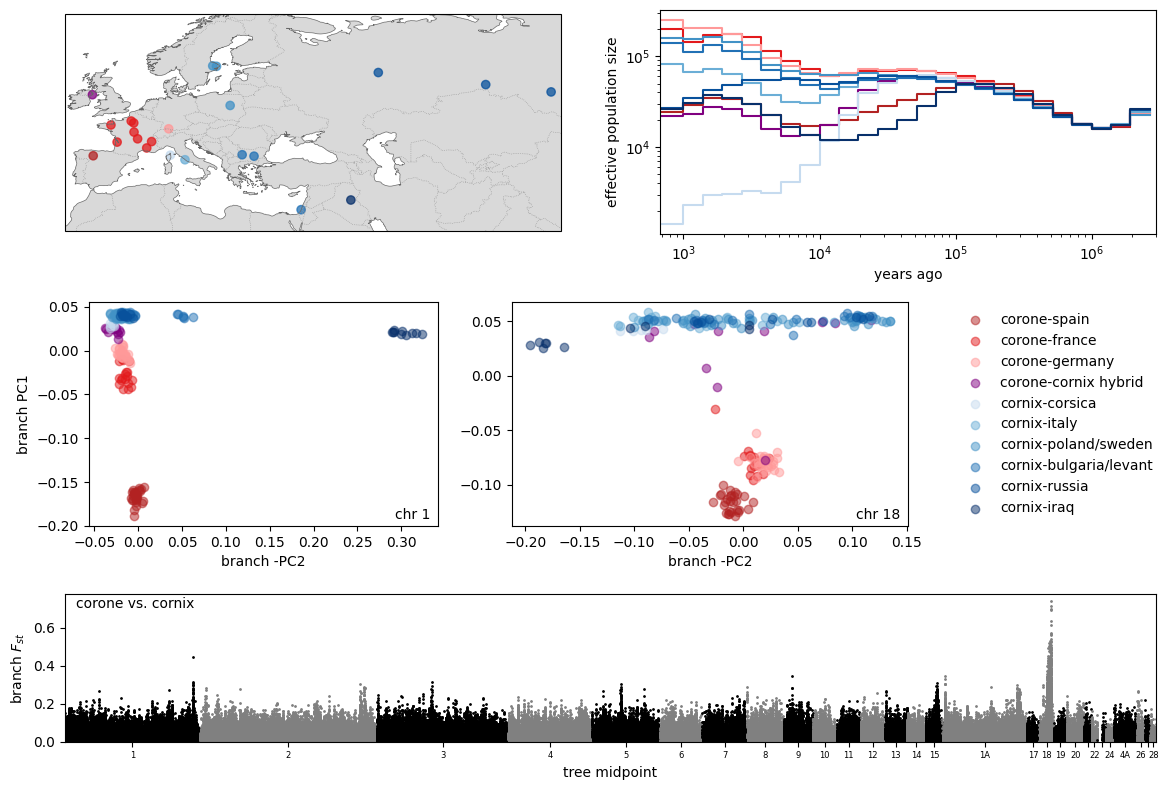

In [15]:
fig = plt.figure(figsize=(12, 8))
outer_gs = gridspec.GridSpec(3, 1, figure=fig, height_ratios=[1, 1, 0.66])

inner_gs_top = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer_gs[0], wspace=0.2)
ax0 = fig.add_subplot(inner_gs_top[0], projection=ccrs.PlateCarree())
ax1 = fig.add_subplot(inner_gs_top[1])

inner_gs_middle = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer_gs[1], width_ratios=[1, 1, 0.5], wspace=0.15)
ax2 = fig.add_subplot(inner_gs_middle[0])
ax3 = fig.add_subplot(inner_gs_middle[1])
ax_legend = fig.add_subplot(inner_gs_middle[2])

# ax0 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
# ax1 = fig.add_subplot(gs[0, 1])
# ax2 = fig.add_subplot(gs[1, 0])
# ax3 = fig.add_subplot(gs[1, 1])
# ax4 = fig.add_subplot(gs[2, :])  # spans all columns in the bottom row

ax4 = fig.add_subplot(outer_gs[2,0])

##############
# map
##############

ax0.add_feature(cfeature.LAND, facecolor='#d9d9d9', edgecolor='none')
ax0.add_feature(cfeature.OCEAN, facecolor='#ffffff')
ax0.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor='#666666')
ax0.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5, edgecolor='#999999')
ax0.set_extent([-11, 85, 28, 70], crs=ccrs.PlateCarree())

unique_locations, ixs = np.unique([[i[-2],i[-1]] for i in sample_data_filtered], axis=0, return_index=True)

ax0.scatter([i[0] for i in unique_locations], [i[1] for i in unique_locations], color=[colormap[i[1]] for i in [sample_data_filtered[j] for j in ixs]], alpha=0.75, marker='o', transform=ccrs.PlateCarree())


##############
# Ne
##############

coal_files = sorted(glob.glob("../data/relate_*_popsize.pairwise.coal"))  # adjust pattern to match your files
years_per_gen = 5.79

def parse_coal(path):
    with open(path) as f:
        lines = f.readlines()
    group_names = lines[0].split()
    epoch_times = [float(x) for x in lines[1].split()]
    rows = {}
    for line in lines[2:]:
        parts = line.split()
        if not parts:
            continue
        i, j = int(parts[0]), int(parts[1])
        rates = [float(x) for x in parts[2:]]
        rows[(i, j)] = rates
    return group_names, epoch_times, rows

def count_trees(anc_path):
    with open(anc_path) as f:
        for line in f:
            if line.startswith("NUM_TREES"):
                return int(line.split()[1])
    raise ValueError(f"NUM_TREES not found in {anc_path}")

# Map each coal file to its corresponding .anc file to get tree counts
anc_files = [f.replace("pairwise.coal", "anc") for f in coal_files]  # adjust naming pattern
weights = np.array([count_trees(f) for f in anc_files], dtype=float)
weights /= weights.sum()

all_parsed = [parse_coal(f) for f in coal_files]
group_names, epoch_times, _ = all_parsed[0]

for pop in poporder:

    pop_idx = np.where(np.array(group_names)==pop)[0][0]
    
    rate_matrix = []
    for gn, et, rows in all_parsed:
        key = (pop_idx, pop_idx)
        rate_matrix.append(rows[key])

    rate_matrix = np.array(rate_matrix)  # shape: (n_chroms, n_epochs)

    # Weighted average across chromosomes, weighted by tree count
    weighted_rate = np.average(rate_matrix, axis=0, weights=weights)
    ne = [1 / (2 * r) if r > 0 else float("nan") for r in weighted_rate]
    times_years = [t * years_per_gen for t in epoch_times[:len(ne)]]

    ax1.step(times_years, ne, where="post", label=labelmap[pop], color=colormap[pop])

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("years ago", fontsize=10)
ax1.set_ylabel("effective population size", fontsize=10)
ax1.set_xlim(None,3e6)

##############
# chr1 pca
##############
chrname = 'NC_046332.1'
pcafactors = np.load('../data/pca_%s.npy' %chrname)
        
for pop in poporder:
    data = pcafactors[np.where(np.array(poplabels)==pop)]
    # ax.scatter(-data[:,1], -data[:,0], color=colormap[pop], alpha=0.5, marker=markermap[pop], label=labelmap[pop])
    ax2.scatter(-data[:,1], data[:,0], color=colormap[pop], alpha=0.5, marker='o', label=labelmap[pop])

# plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
# plt.legend()
ax2.set_xlabel('branch -PC2', fontsize=10)
ax2.set_ylabel('branch PC1', fontsize=10)
ax2.set_aspect(1)
ax2.text(0.98, 0.02, "chr 1", transform=ax2.transAxes,
          ha='right', va='bottom', fontsize=10)

# Shared legend combining handles from both axes, placed below both panels
# fig.legend(handles=[line1, line2], loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=2)
# handles, labels = ax2a.get_legend_handles_labels()
# fig.legend(handles=handles, labels=labels, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=len(handles))

##############
# chr18 pca
##############
chrname = 'NC_046347.1'
pcafactors = np.load('../data/pca_%s.npy' %chrname)
        
for pop in poporder:
    data = pcafactors[np.where(np.array(poplabels)==pop)]
    # ax.scatter(-data[:,1], -data[:,0], color=colormap[pop], alpha=0.5, marker=markermap[pop], label=labelmap[pop])
    ax3.scatter(-data[:,1], data[:,0], color=colormap[pop], alpha=0.5, marker='o', label=labelmap[pop])

# ax3.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
# plt.legend()
ax3.set_xlabel('branch -PC2', fontsize=10)
# ax3.set_ylabel('branch PC1', fontsize=10)
ax3.set_aspect(1)
ax3.text(0.98, 0.02, "chr 18", transform=ax3.transAxes,
          ha='right', va='bottom', fontsize=10)

##############
# legend
##############

ax_legend.axis('off')
handles, labels = ax3.get_legend_handles_labels()
ax_legend.legend(handles=handles, labels=labels, loc='center', frameon=False)

##############
# fst
##############

end = 0
xticks = []
for i,[b,f] in enumerate(zip(windows,fst)):
    ax4.scatter([end+i for i in b[:-1]],f,color=colors(i),s=1)
    xticks.append(end + b[-1]/2)
    end += b[-1]
    
# plt.plot([0,end],[0.2,0.2],'--k')
ax4.set_xlim(0,end)
ax4.set_ylim(0,None)
ticks = ['' if c[3:] in {'21','23','27'} else c[3:] for c in chrmap.keys()]
ax4.set_xticks(xticks, ticks, fontsize=6)
ax4.set_ylabel(r'branch $F_{st}$', fontsize=10)
ax4.set_xlabel('tree midpoint', fontsize=10)
ax4.text(0.01, 0.98, "corone vs. cornix", transform=ax4.transAxes,
          ha='left', va='top', fontsize=10)

plt.tight_layout()
plt.savefig('../plots/fig1.png', dpi=300)
plt.show()

# Figure 2

## coalescent times on chr18

In [17]:
chrname = 'NC_046347.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
ts

In [18]:
window = list(ts.breakpoints())
windows = [(i+j)/2 for i,j in zip(window[1:],window[:-1])]

In [19]:
# coroneix = [i for i,j in enumerate(poplabels) if j[2]=='r']
# cornixix = [i for i,j in enumerate(poplabels) if j[2]=='x']
# maxtmrcas = []
# mintmrcas = []
# for tree in ts.trees():
#     maxtmrca = [0,0]
#     for n,ixs in enumerate([coroneix,cornixix]):
#         for i in ixs:
#             for j in ixs[:i]:
#                 tmrca = tree.tmrca(i,j)
#                 if tmrca > maxtmrca[n]:
#                     maxtmrca[n] = tmrca
#     maxtmrcas.append(maxtmrca)
#     mintmrca = tree.time(tree.root)
#     for i in coroneix:
#         for j in cornixix:
#             tmrca = tree.tmrca(i,j)
#             if tmrca < mintmrca:
#                 mintmrca = tmrca
#     mintmrcas.append(mintmrca)
# np.save('../data/maxtmrcas_chr18.npy', np.array(maxtmrcas))
# np.save('../data/mintmrcas_chr18.npy', np.array(mintmrcas))
maxtmrcas = np.load('../data/maxtmrcas_chr18.npy')
mintmrcas = np.load('../data/mintmrcas_chr18.npy')

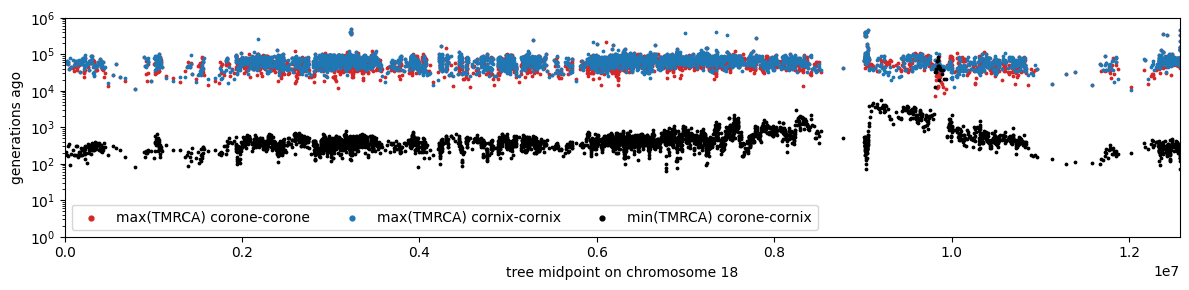

In [20]:
fig = plt.figure(figsize=(12,3))
ax = plt.axes() 

ax.scatter(windows, maxtmrcas[:,0], s=3, marker='o', label='max(TMRCA) corone-corone', color=plt.cm.tab10(3))
ax.scatter(windows, maxtmrcas[:,1], s=3, marker='o', label='max(TMRCA) cornix-cornix', color=plt.cm.tab10(0))
ax.scatter(windows, mintmrcas, s=3, marker='o', label='min(TMRCA) corone-cornix', color='k')

ax.set_xlim(0,windows[-1])
ax.set_yscale('log')
ax.set_ylim(1,1e6)
ax.set_xlabel('tree midpoint on chromosome 18')
ax.set_ylabel('generations ago')
plt.legend(ncols=3, markerscale=2)
plt.tight_layout()

# plt.savefig('plots/tmrcas_chr18.png')
plt.show()

## dolores

In [21]:
chrname = 'NC_046347.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
window = list(ts.breakpoints())
windows = [(i+j)/2 for i,j in zip(window[1:],window[:-1])]

dol_data = []
with open('../data/relate_%s_popsize_output/relate_%s_popsize_output.csv' %(chrname,chrname),'r') as f:
    for i,line in enumerate(f):
        if i==0:
            print(line)
        else:
            dol_data.append(line.split(','))

name,genetic_map,total_clades,clade_num,clade_id,nlog10p_test1,nlog10p_test2,cladesize,span,start,end,mut_span,left_mut,right_mut,num_mutations,merged,chunk_index,tree_index,node_id



In [22]:
for i,d in enumerate(dol_data):
    if float(d[6])>2:
        suspect = d
suspect

['relate_NC_046347.1_popsize',
 'HapMapII_GRCh37',
 '246054',
 '218412',
 '127',
 '3.436181746088113e-11',
 '2.498860202214927',
 '67',
 '98663',
 '9699387',
 '9798050',
 '71039',
 '9714848',
 '9785887',
 '4',
 '2',
 '3',
 '355',
 '161708\n']

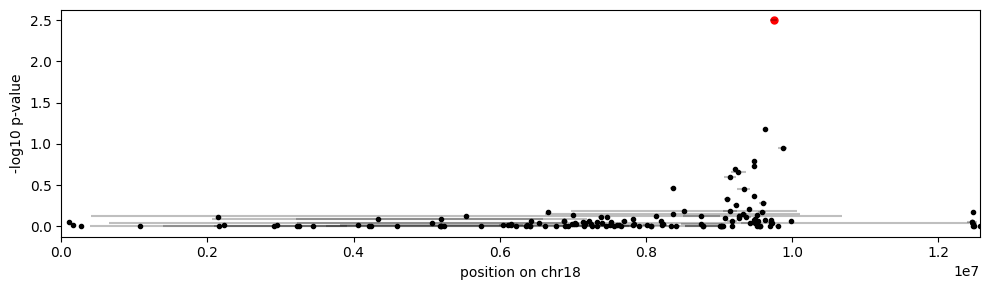

In [23]:
fig = plt.figure(figsize=(10,3))
ax = plt.axes()

pos = [(int(i[10])+int(i[9]))/2 for i in dol_data]
# plt.scatter(pos,[float(i[5]) for i in dol_data], marker='.') #test 1 (nothing significant)
ax.scatter(pos,[float(i[6]) for i in dol_data], marker='.', c='k') #test 2
ax.hlines(xmin=[int(i[9]) for i in dol_data],xmax=[int(i[10]) for i in dol_data],y=[float(i[6]) for i in dol_data], color='k', alpha=0.25)
ax.scatter(pos[int(suspect[4])],[float(i[6]) for i in dol_data][int(suspect[4])], marker='.', c='r', s=100) #test 2 most likely candidate

ax.set_xlim(0,windows[-1])
# ax.set_ylim(0,100) #comment out to see the two clades we are ignoring
ax.set_ylabel('-log10 p-value')
ax.set_xlabel('position on chr18')

plt.tight_layout()
# plt.savefig('plots/dolores-chr18.png')
plt.show()

In [24]:
-np.log(0.05)

np.float64(2.995732273553991)

the top candidate is

In [25]:
ts = tskit.load('../data/relate_%s_popsize_output/relate_%s_popsize_chunk%s.trees' %(chrname,chrname,suspect[-3]))
tree = ts.at_index(int(suspect[-2]))

In [26]:
styles = []
for i in ts.samples():
    if poplabels[i][2]=='r':
        color = 'red'
    elif poplabels[i][2]=='x':
        color = 'blue'
    elif poplabels[i][3]=='1':
        color = 'purple'
    s = f".n{i} > .sym " + "{" + f"fill: {color}" + "}"    
    styles.append(s)
i = suspect[-1]
color = 'red'
styles.append(f".n{i} > .sym " + "{" + f"fill: {color}" + "}")
css_string = " ".join(styles)

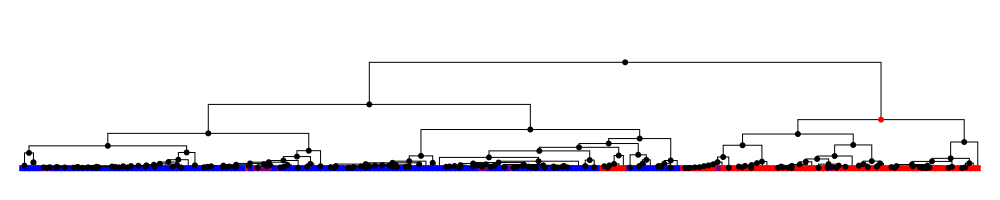

In [27]:
dtree_svg = tree.draw_svg(
    size=(1000,200),
    node_labels={}, mutation_labels={}, style=css_string, omit_sites=True,
    # time_scale="log_time",  
    # y_axis=True, 
    # y_gridlines=True, 
    # y_ticks=[10, 100, 1000, 10000, 100000], 
    # y_label="generations ago",
    # path='plots/fst_tree.svg'
    max_time=100000
)
dtree_svg

## trees

In [28]:
chrname = 'NC_046347.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
fst = np.load('../data/fst_%s.npy' %chrname)

In [29]:
styles = []
for i in ts.samples():
    if poplabels[i][2]=='r':
        color = 'red'
    elif poplabels[i][2]=='x':
        color = 'blue'
    else:
        color = 'purple'
    s = f".n{i} .sym " + "{" + f"fill: {color}" + "}"    
    styles.append(s)
css_string = " ".join(styles)

3376


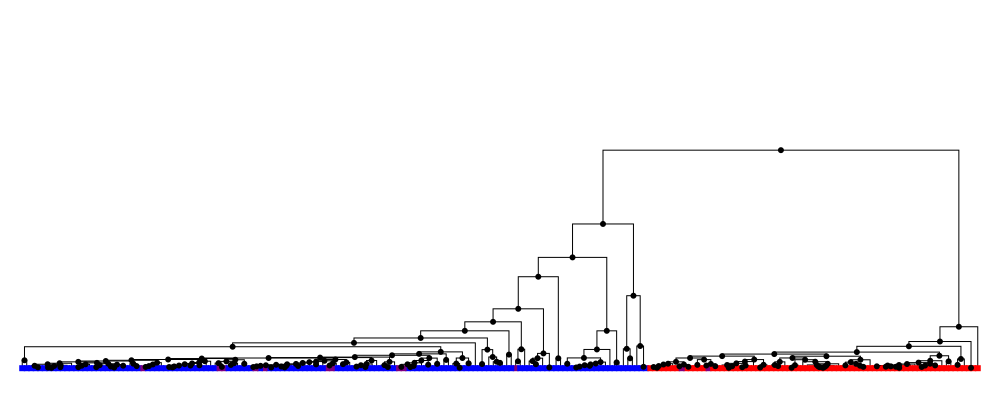

In [30]:
peak = np.nanargmax(fst)
print(peak)
tree = ts.at_index(peak)
tree_svg = tree.draw_svg(
    size=(1000,400),
    node_labels={}, mutation_labels={}, style=css_string, omit_sites=True,
    # time_scale="log_time",  
    # y_axis=True, 
    # y_gridlines=True, 
    # y_ticks=[10, 100, 1000, 10000, 100000], 
    # y_label="generations ago",
    # path='plots/fst_tree.svg'
    max_time=100000
)
tree_svg

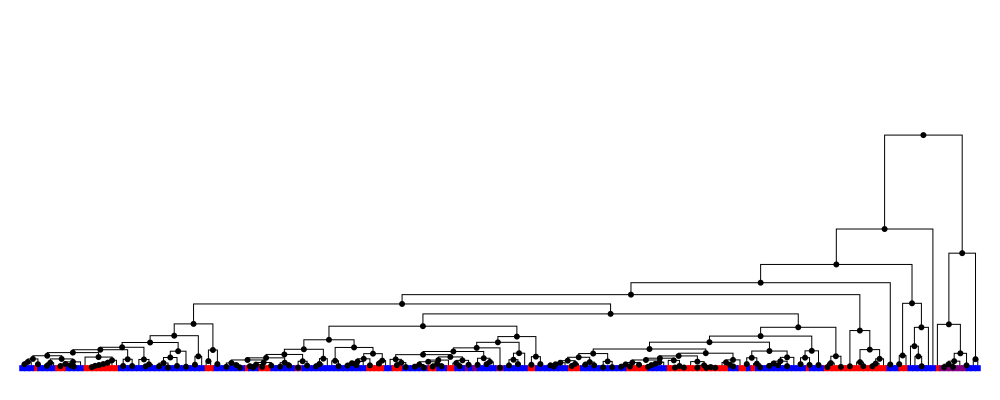

In [31]:
tree = ts.at_index(100)
rtree_svg = tree.draw_svg(
    size=(1000,400),
    node_labels={}, mutation_labels={}, style=css_string, omit_sites=True,
    # time_scale="log_time",  
    # y_axis=True, 
    # y_gridlines=True,
    # y_ticks=[10, 100, 1000, 10000, 100000], y_label="generations ago",
    # path='plots/fst_tree.svg'
    max_time=100000
)
rtree_svg

## all together now

/tmp/ipykernel_1598776/1948357737.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


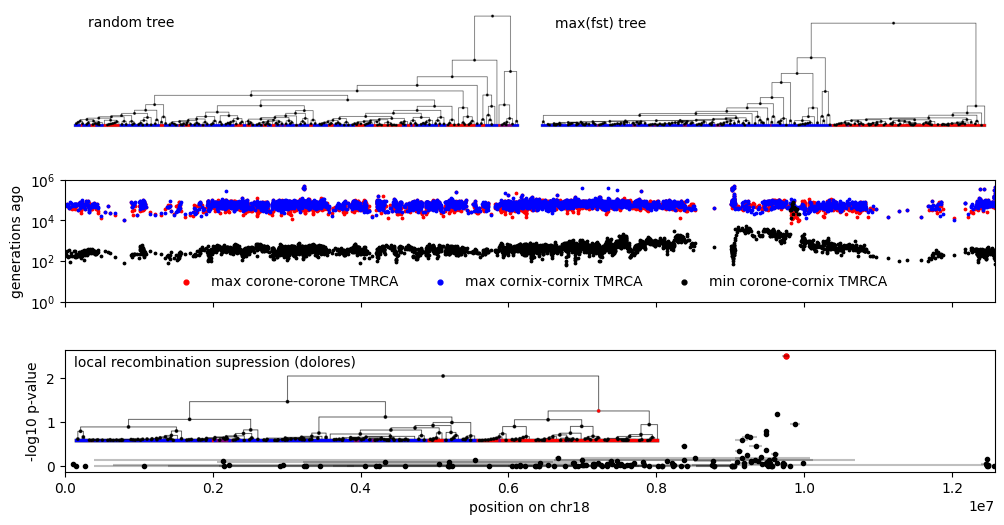

In [32]:
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 1], wspace=0.01, hspace=0.4)

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, :])
ax3 = fig.add_subplot(gs[2, :])

############
# trees
############

png_bytes = cairosvg.svg2png(bytestring=rtree_svg.encode('utf-8'), scale=5)  # scale up for resolution
img = mpimg.imread(io.BytesIO(png_bytes), format='png')
top_px = int(img.shape[0] * 0.3)
bottom_px = int(img.shape[0] * (1 - 0.05))
img_cropped = img[top_px:bottom_px, :, :]
ax0.imshow(img_cropped, aspect='auto')
ax0.axis('off')
ax0.text(0.05, 0.95, "random tree", transform=ax0.transAxes,
          ha='left', va='top', fontsize=10)

png_bytes = cairosvg.svg2png(bytestring=tree_svg.encode('utf-8'), scale=5)  # scale up for resolution
img = mpimg.imread(io.BytesIO(png_bytes), format='png')
top_px = int(img.shape[0] * 0.3)
bottom_px = int(img.shape[0] * (1 - 0.05))
img_cropped = img[top_px:bottom_px, :, :]
ax1.imshow(img_cropped, aspect='auto')
ax1.axis('off')
ax1.text(0.05, 0.95, "max(fst) tree", transform=ax1.transAxes,
          ha='left', va='top', fontsize=10)

############
# tmrcas
############

ax2.scatter(windows, maxtmrcas[:,0], s=3, marker='o', label='max corone-corone TMRCA', color='red')
ax2.scatter(windows, maxtmrcas[:,1], s=3, marker='o', label='max cornix-cornix TMRCA', color='blue')
ax2.scatter(windows, mintmrcas, s=3, marker='o', label='min corone-cornix TMRCA', color='k')

ax2.set_xlim(0,windows[-1])
ax2.set_yscale('log')
ax2.set_ylim(1,1e6)
# ax2.set_xlabel('tree midpoint on chromosome 18')
ax2.set_xticklabels([])
ax2.set_ylabel('generations ago')
ax2.legend(ncols=3, markerscale=2,frameon=False, loc='lower center')

############
# delores
############

pos = [(int(i[10])+int(i[9]))/2 for i in dol_data]
# plt.scatter(pos,[float(i[5]) for i in dol_data], marker='.') #test 1 (nothing significant)
ax3.scatter(pos,[float(i[6]) for i in dol_data], marker='.', c='k') #test 2
ax3.hlines(xmin=[int(i[9]) for i in dol_data],xmax=[int(i[10]) for i in dol_data],y=[float(i[6]) for i in dol_data], color='k', alpha=0.25)
ax3.scatter(pos[int(suspect[4])],[float(i[6]) for i in dol_data][int(suspect[4])], marker='.', c='r', s=50) #test 2 most likely candidate


ax3.set_xlim(0,windows[-1])
# ax.set_ylim(0,100) #comment out to see the two clades we are ignoring
ax3.set_ylabel('-log10 p-value')
ax3.set_xlabel('position on chr18')
ax3.text(0.01, 0.95, "local recombination supression (dolores)", transform=ax3.transAxes,
          ha='left', va='top', fontsize=10)

png_bytes = cairosvg.svg2png(bytestring=dtree_svg.encode('utf-8'), scale=5)
img = mpimg.imread(io.BytesIO(png_bytes), format='png')

# Create an inset axes positioned within ax1's coordinate space
# [x0, y0, width, height] in axes-fraction (0-1) coordinates
axins = ax3.inset_axes([-0.3, 0.1, 1.25, 1])
axins.imshow(img)
axins.axis('off')

plt.tight_layout()
plt.savefig('../plots/fig2.png', dpi=300)
plt.show()

now need to show where trees are coming from with zoom out triangles

# time stratified PCA

In [42]:
poporder = ['cor1','cor3','cor2',
            'hyb1',
            'cnx5','cnx1','cnx3','cnx2','cnx4','cnx6',
            ]
colormap = {
    'cor1': "#B22222", 'cor3': "#E31A1C", 'cor2': "#FF9999", 
    'hyb1': 'purple',     
    'cnx6': "yellow", 'cnx4': "#08519C", 'cnx2': "#2171B5", 'cnx3':"#4292C6", 'cnx1':"#6BAED6", 'cnx5':"#C6DBEF"
}
markermap = {
    'cor1': '<', 'cor2': '>', 'cor3': 'o', 
    'hyb1': 'X',     
    'cnx1': 'o', 'cnx2': 's', 'cnx3': '^', 'cnx4': '>', 'cnx5': '<', 'cnx6': 'v'
}
labelmap = {
    'cor1': 'corone-spain', 'cor2': 'corone-germany', 'cor3': 'corone-france', 
    'hyb1': 'corone-cornix hybrid',     
    'cnx1': 'cornix-italy', 'cnx2': 'cornix-bulgaria/levant', 'cnx3': 'cornix-poland/sweden', 'cnx4': 'cornix-russia', 'cnx5': 'cornix-corsica', 'cnx6': 'cornix-iraq'
}

## chr 18

In [43]:
chrname = 'NC_046347.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
# pca = ts.pca(2, random_seed=1) #run pca with 2 axes
# np.save('../data/pca_%s.npy' %chrname, pca.factors)

In [44]:
# tws = [[0,1e3],[1e3,1e4],[1e4,1e5]]
tws = [[0,1e4/6],[1e4/6,2e4/6],[2e4/6,1e5]]
pcas=[]
for tw in tws:
    pcas.append(ts.pca(2, random_seed=1, time_windows=tw)) 

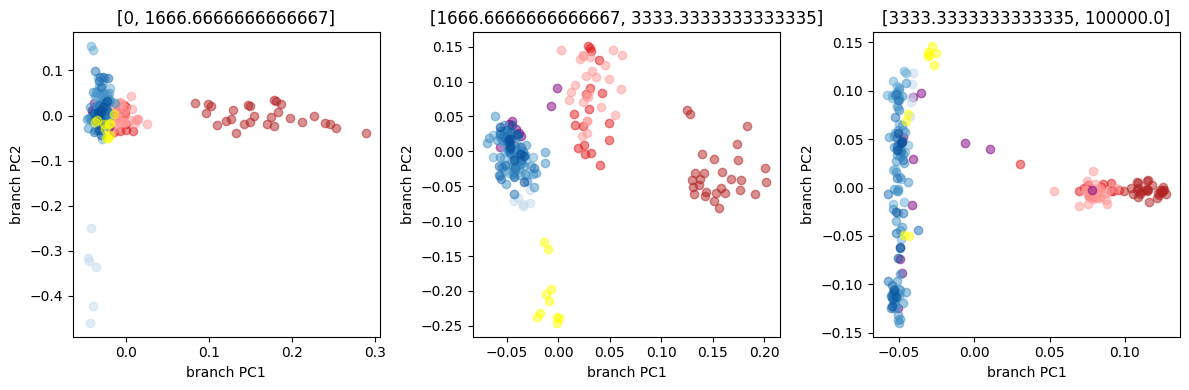

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
# fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for i, ax in enumerate(axes):

    for pop in poporder:
        data = pcas[i].factors[np.where(np.array(poplabels)==pop)]
        # if pop == 'cnx6':
        #     for j in zip([i[0] for i in sample_data if i[1]=='cnx6'],data):
        #         print(j)
        # ax.scatter(-data[:,1], -data[:,0], color=colormap[pop], alpha=0.5, marker=markermap[pop], label=labelmap[pop])
        ax.scatter(-data[:,0], -data[:,1], color=colormap[pop], alpha=0.5, marker='o', label=labelmap[pop])
    
    # plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
    ax.set_xlabel('branch PC1', fontsize=10)
    ax.set_ylabel('branch PC2', fontsize=10)
    # ax.set_aspect(1)
    ax.set_title(tws[i])
    
plt.tight_layout()
# plt.savefig('plots/pca_%s.png' %chrname)
plt.show()

## chr1

In [13]:
chrname = 'NC_046332.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
# pca = ts.pca(2, random_seed=1) #run pca with 2 axes
# np.save('../data/pca_%s.npy' %chrname, pca.factors)

In [14]:
tws = [[0,1e3],[1e3,1e4],[1e4,1e5]]
pcas=[]
for tw in tws:
    pcas.append(ts.pca(2, random_seed=1, time_windows=tw)) #run pca with 2 axes

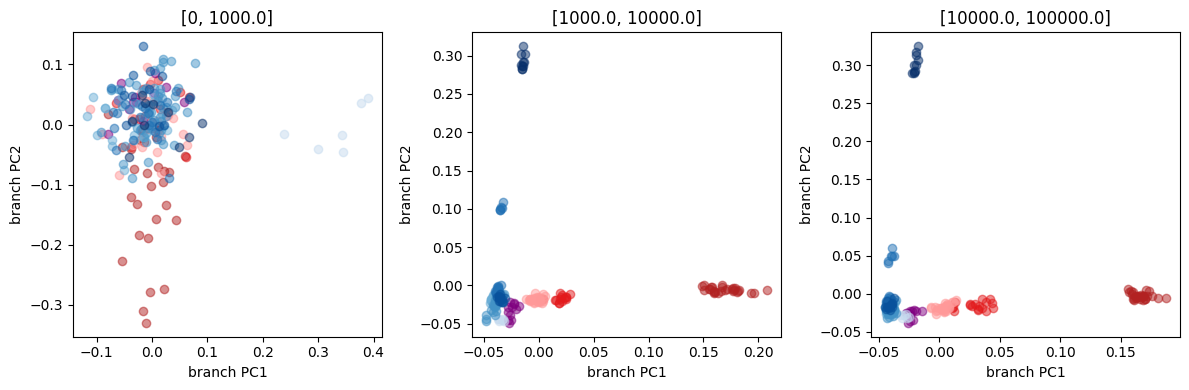

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, ax in enumerate(axes):

    for pop in poporder:
        data = pcas[i].factors[np.where(np.array(poplabels)==pop)]
        # ax.scatter(-data[:,1], -data[:,0], color=colormap[pop], alpha=0.5, marker=markermap[pop], label=labelmap[pop])
        ax.scatter(-data[:,0], -data[:,1], color=colormap[pop], alpha=0.5, marker='o', label=labelmap[pop])
    
    # plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
    ax.set_xlabel('branch PC1', fontsize=10)
    ax.set_ylabel('branch PC2', fontsize=10)
    # ax.set_aspect(1)
    ax.set_title(tws[i])
    
plt.tight_layout()
# plt.savefig('plots/pca_%s.png' %chrname)
plt.show()

# coalescent-based time-stratified statistics

In [7]:
# https://github.com/YunDeng98/Coalescent-based-time-stratified-statistics/blob/main/time_stratified_stats.py#L834
def coalescence_based_f2(
    ts,
    groups,
    time_windows
):
    """
    Compute the coalescence-based f2 statistic across user-specified time windows.

    Parameters
    ----------
    ts : tskit.TreeSequence
        Input tree sequence.
    groups : sequence of two sample sets
        Sample node IDs for [A, B].
    time_windows : array_like
        Strictly increasing finite boundaries for the intervals of interest.

    Returns
    -------
    f2_values : ndarray
        Coalescence-based f2 statistic for each user-specified interval.
    """
    if len(groups) != 2:
        raise ValueError("groups must contain two sample sets: [A, B].")

    time_windows = np.asarray(time_windows, dtype=float)

    if time_windows.ndim != 1 or time_windows.size < 2:
        raise ValueError("time_windows must contain at least two boundaries.")

    if np.any(~np.isfinite(time_windows)):
        raise ValueError(
            "User-supplied time_windows must be finite; "
            "0 and np.inf are added internally."
        )

    if np.any(time_windows < 0):
        raise ValueError("time_windows must be nonnegative.")

    if np.any(np.diff(time_windows) <= 0):
        raise ValueError("time_windows must be strictly increasing.")

    group_a, group_b = groups

    tskit_time_windows = np.concatenate(
        ([0.0], time_windows, [np.inf])
    )
    
    # Within-group A: supplying one sample set computes pairs within that set.
    aa_counts = np.asarray(
        ts.pair_coalescence_counts(
            sample_sets=[group_a],
            time_windows=tskit_time_windows
        ),
        dtype=float,
    )

    # Within-group B.
    bb_counts = np.asarray(
        ts.pair_coalescence_counts(
            sample_sets=[group_b],
            time_windows=tskit_time_windows
        ),
        dtype=float,
    )

    # Between groups A and B.
    ab_counts = np.asarray(
        ts.pair_coalescence_counts(
            sample_sets=[group_a, group_b],
            time_windows=tskit_time_windows
        ),
        dtype=float,
    )

    aa_remaining = np.cumsum(aa_counts[::-1])[::-1]
    bb_remaining = np.cumsum(bb_counts[::-1])[::-1]
    ab_remaining = np.cumsum(ab_counts[::-1])[::-1]

    aa_probabilities = np.divide(
        aa_counts,
        aa_remaining,
        out=np.zeros_like(aa_counts),
        where=aa_remaining > 0,
    )

    bb_probabilities = np.divide(
        bb_counts,
        bb_remaining,
        out=np.zeros_like(bb_counts),
        where=bb_remaining > 0,
    )

    ab_probabilities = np.divide(
        ab_counts,
        ab_remaining,
        out=np.zeros_like(ab_counts),
        where=ab_remaining > 0,
    )

    aa_probabilities = aa_probabilities[1:-1]
    bb_probabilities = bb_probabilities[1:-1]
    ab_probabilities = ab_probabilities[1:-1]

    f2_values = (
        aa_probabilities
        + bb_probabilities
        - 2 * ab_probabilities
    )

    return f2_values, aa_probabilities, bb_probabilities, ab_probabilities

In [8]:
tws = np.linspace(0,100000,11)
tws

array([     0.,  10000.,  20000.,  30000.,  40000.,  50000.,  60000.,
        70000.,  80000.,  90000., 100000.])

In [9]:
cor,cnx = [], []
for i,p in enumerate(poplabels):
    if p[2]=='r':
        cor.append(i)
    elif p[2]=='x':
        cnx.append(i)

In [12]:
chrname = 'NC_046347.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
f2,paa,pbb,pab = coalescence_based_f2(ts, [cor,cnx], tws)

In [13]:
chrname = 'NC_046332.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
f2_chr1,paa1,pbb1,pab1 = coalescence_based_f2(ts, [cor,cnx], tws)

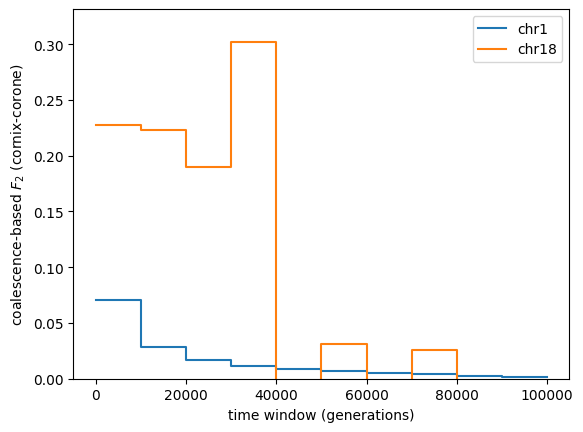

In [14]:
plt.step(tws, np.append(f2_chr1,f2_chr1[-1]), where="post", label="chr1")
plt.step(tws, np.append(f2,f2[-1]), where="post", label="chr18")
plt.xlabel('time window (generations)')
plt.ylabel('coalescence-based $F_2$ (cornix-corone)')
plt.ylim(0,None)
plt.legend()
plt.show()

reasonable: more diveregnce on 18 and all collapse to panmictic at ~40000 gens ago

In [15]:
tws = np.linspace(0,4000,9)
tws

array([   0.,  500., 1000., 1500., 2000., 2500., 3000., 3500., 4000.])

In [16]:
chrname = 'NC_046347.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
f2_recent, paa, pbb, pab = coalescence_based_f2(ts, [cor,cnx], tws)

In [17]:
chrname = 'NC_046332.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
f2_chr1_recent, paa1, pbb1, pab1 = coalescence_based_f2(ts, [cor,cnx], tws)

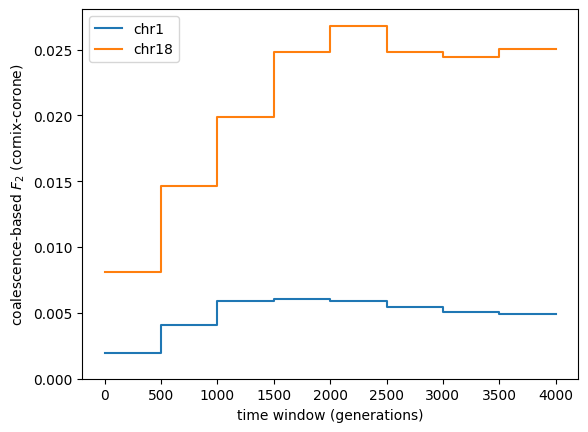

In [18]:
plt.step(tws, np.append(f2_chr1_recent,f2_chr1_recent[-1]), where="post", label="chr1")
plt.step(tws, np.append(f2_recent,f2_recent[-1]), where="post", label="chr18")
plt.xlabel('time window (generations)')
plt.ylabel('coalescence-based $F_2$ (cornix-corone)')
plt.ylim(0,None)
plt.legend()
plt.show()

reasonable: more divergence on 18 and increasing homogenization towards the present day

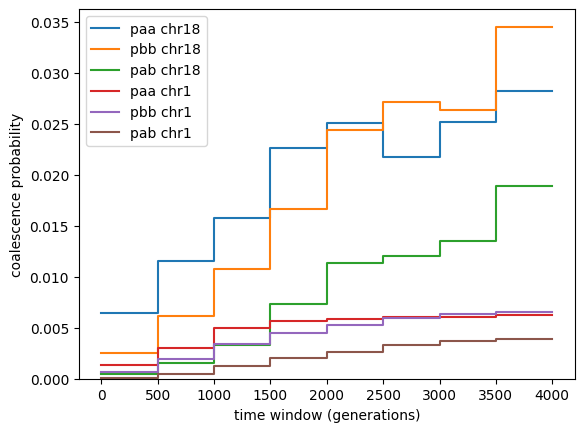

In [19]:
plt.step(tws, np.append(paa,paa[-1]), where="post", label="paa chr18")
plt.step(tws, np.append(pbb,pbb[-1]), where="post", label="pbb chr18")
plt.step(tws, np.append(pab,pab[-1]), where="post", label="pab chr18")
plt.step(tws, np.append(paa1,paa1[-1]), where="post", label="paa chr1")
plt.step(tws, np.append(pbb1,pbb1[-1]), where="post", label="pbb chr1")
plt.step(tws, np.append(pab1,pab1[-1]), where="post", label="pab chr1")
plt.xlabel('time window (generations)')
plt.ylabel('coalescence probability')
plt.ylim(0,None)
plt.legend()
plt.show()

note that despite elevated F2 on chr18, the rate of coalescence between cor and cnx on 18 is higher than it is on chr1 - coal rate is generally higher on chr18, perhaps due to recent sweeps?

In [74]:
cor2,cnx3 = [], []
for i,p in enumerate(poplabels):
    if p=='cor2':
        cor2.append(i)
    elif p=='cnx3':
        cnx3.append(i)

In [75]:
chrname = 'NC_046347.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
f2_recent = coalescence_based_f2(ts, [cor2,cnx3], tws)

In [76]:
chrname = 'NC_046332.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
f2_chr1_recent = coalescence_based_f2(ts, [cor2,cnx3], tws)

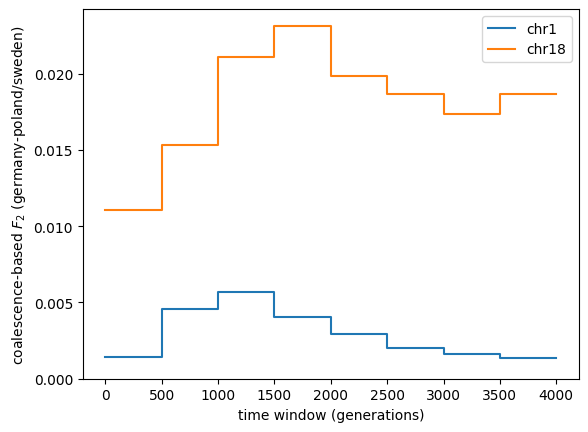

In [77]:
plt.step(tws, np.append(f2_chr1_recent,f2_chr1_recent[-1]), where="post", label="chr1")
plt.step(tws, np.append(f2_recent,f2_recent[-1]), where="post", label="chr18")
plt.xlabel('time window (generations)')
plt.ylabel('coalescence-based $F_2$ (germany-poland/sweden)')
plt.ylim(0,None)
plt.legend()
plt.show()

In [20]:
def coalescence_based_f4(
    ts,
    groups,
    time_windows,
):
    """
    Compute the coalescence-based f4 statistic across user-specified time windows.

    The supplied ``time_windows`` define the intervals of interest. Internally,
    0 and infinity are added because ``tskit.pair_coalescence_counts`` requires
    the full range [0, ..., inf]. The extra first and last intervals are removed
    before returning the result.

    Parameters
    ----------
    ts : tskit.TreeSequence
        Input tree sequence.
    groups : sequence of four sample sets
        Sample node IDs for [A, B, C, D].
    time_windows : array_like
        Strictly increasing boundaries for the intervals of interest.
        For example, [100, 500, 1000] defines:
        [100, 500) and [500, 1000).

    Returns
    -------
    f4_values : ndarray
        Coalescence-based f4 statistic for each user-specified interval.
    """
    if len(groups) != 3:
        raise ValueError("groups must contain three sample sets: [A, B, C].")

    time_windows = np.asarray(time_windows, dtype=float)

    if time_windows.ndim != 1 or time_windows.size < 2:
        raise ValueError("time_windows must contain at least two boundaries.")

    if np.any(~np.isfinite(time_windows)):
        raise ValueError(
            "User-supplied time_windows must be finite; "
            "0 and np.inf are added internally."
        )

    if np.any(time_windows < 0):
        raise ValueError("time_windows must be nonnegative.")

    if np.any(np.diff(time_windows) <= 0):
        raise ValueError("time_windows must be strictly increasing.")

    group_a, group_b, group_c = groups

    # tskit requires the windows to span from 0 to infinity.
    tskit_time_windows = np.concatenate(
        ([0.0], time_windows, [np.inf])
    )

    ac_counts = np.asarray(
        ts.pair_coalescence_counts(
            sample_sets=[group_a, group_c],
            time_windows=tskit_time_windows,
        ),
        dtype=float,
    )

    bc_counts = np.asarray(
        ts.pair_coalescence_counts(
            sample_sets=[group_b, group_c],
            time_windows=tskit_time_windows,
        ),
        dtype=float,
    )

    ac_remaining = np.cumsum(ac_counts[::-1])[::-1]
    bc_remaining = np.cumsum(bc_counts[::-1])[::-1]

    ac_probabilities = np.divide(
        ac_counts,
        ac_remaining,
        out=np.zeros_like(ac_counts),
        where=ac_remaining > 0,
    )

    bc_probabilities = np.divide(
        bc_counts,
        bc_remaining,
        out=np.zeros_like(bc_counts),
        where=bc_remaining > 0,
    )

    # Remove the internally added [0, first_boundary) and
    # [last_boundary, infinity) intervals.
    ac_probabilities = ac_probabilities[1:-1]
    bc_probabilities = bc_probabilities[1:-1]

    f4_values = 2 * (
        ac_probabilities
        - bc_probabilities
    )

    return f4_values, ac_probabilities, bc_probabilities

In [21]:
irq,cor,cnx = [], [], []
for i,p in enumerate(poplabels):
    if p=='cnx6':
        irq.append(i)
    elif p[2]=='r':
        cor.append(i)
    elif p[2]=='x':
        cnx.append(i)

In [22]:
tws = np.linspace(0,4000,9)
tws

array([   0.,  500., 1000., 1500., 2000., 2500., 3000., 3500., 4000.])

In [23]:
chrname = 'NC_046347.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
f4_chr18, pac_18, pbc_18 = coalescence_based_f4(ts, [irq,cnx,cor], tws)

In [24]:
chrname = 'NC_046332.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
f4_chr1, pac_1, pbc_1 = coalescence_based_f4(ts, [irq,cnx,cor], tws)

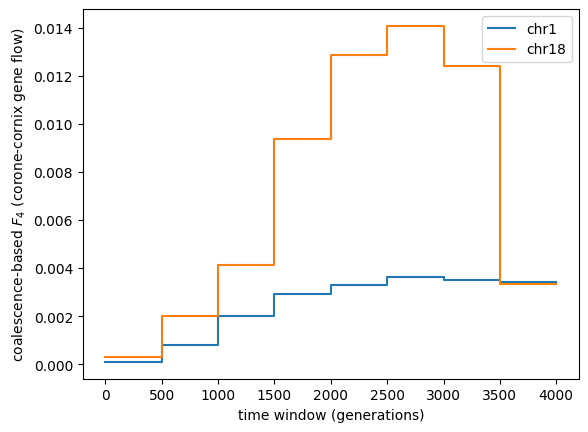

In [25]:
plt.step(tws, -np.append(f4_chr1,f4_chr1[-1]), where="post", label="chr1")
plt.step(tws, -np.append(f4_chr18,f4_chr18[-1]), where="post", label="chr18")
plt.xlabel('time window (generations)')
plt.ylabel('coalescence-based $F_4$ (corone-cornix gene flow)')
# plt.ylim(0,None)
plt.legend()
plt.show()

reasonable: see strengthening barrier (decline of F4 on 18 towards the present).

trickier: more (not less) gene flow between hooded and carrion on 18 vs 1. peaks 2500 gens ago (~15,000 kya). as shown below, this is driven by large coalcence probs between hooded and carrion on 18 -- could have something to do with sweep?

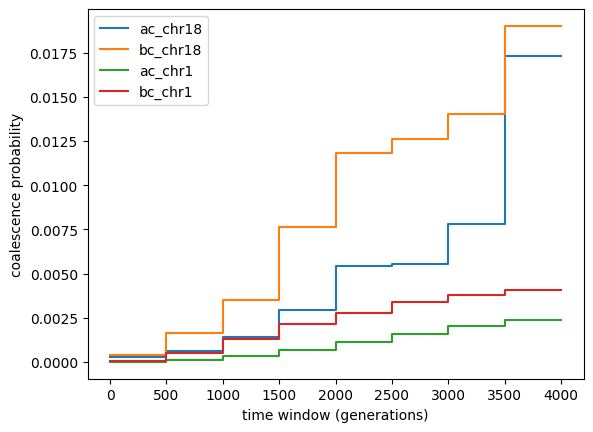

In [90]:
plt.step(tws, np.append(pac_18,pac_18[-1]), where="post", label="ac_chr18")
plt.step(tws, np.append(pbc_18,pbc_18[-1]), where="post", label="bc_chr18")
plt.step(tws, np.append(pac_1,pac_1[-1]), where="post", label="ac_chr1")
plt.step(tws, np.append(pbc_1,pbc_1[-1]), where="post", label="bc_chr1")
plt.xlabel('time window (generations)')
plt.ylabel('coalescence probability')
# plt.ylim(0,None)
plt.legend()
plt.show()

In [91]:
irq,spa,bul = [], [], []
for i,p in enumerate(poplabels):
    if poplabels[i]=='cnx6':
        irq.append(i)
    elif poplabels[i]=='cor1':
        spa.append(i)
    elif poplabels[i]=='cnx2':
        bul.append(i)

In [92]:
tws = np.linspace(0,4000,9)
tws

array([   0.,  500., 1000., 1500., 2000., 2500., 3000., 3500., 4000.])

In [96]:
chrname = 'NC_046347.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
f4_chr18, pac_18, pbc_18 = coalescence_based_f4(ts, [irq,bul,spa], tws)

In [97]:
chrname = 'NC_046332.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
f4_chr1, pac_1, pbc_1 = coalescence_based_f4(ts, [irq,bul,spa], tws)

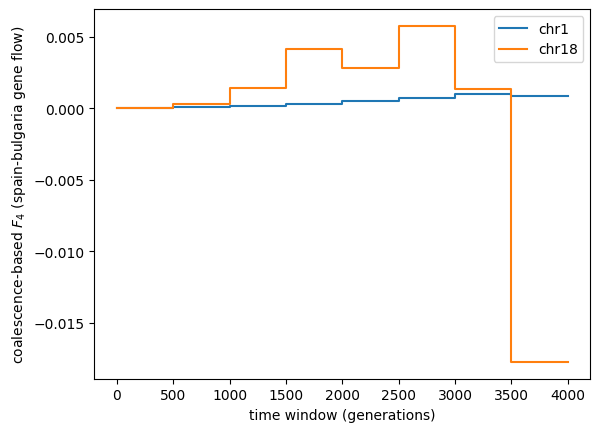

In [98]:
plt.step(tws, -np.append(f4_chr1,f4_chr1[-1]), where="post", label="chr1")
plt.step(tws, -np.append(f4_chr18,f4_chr18[-1]), where="post", label="chr18")
plt.xlabel('time window (generations)')
plt.ylabel('coalescence-based $F_4$ (spain-bulgaria gene flow)')
# plt.ylim(0,None)
plt.legend()
plt.show()

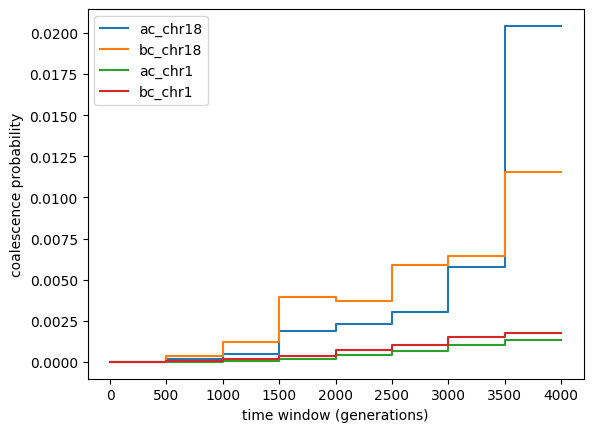

In [99]:
plt.step(tws, np.append(pac_18,pac_18[-1]), where="post", label="ac_chr18")
plt.step(tws, np.append(pbc_18,pbc_18[-1]), where="post", label="bc_chr18")
plt.step(tws, np.append(pac_1,pac_1[-1]), where="post", label="ac_chr1")
plt.step(tws, np.append(pbc_1,pbc_1[-1]), where="post", label="bc_chr1")
plt.xlabel('time window (generations)')
plt.ylabel('coalescence probability')
# plt.ylim(0,None)
plt.legend()
plt.show()

In [100]:
cor2,cnx3 = [], []
for i,p in enumerate(poplabels):
    if p=='cor2':
        cor2.append(i)
    elif p=='cnx3':
        cnx3.append(i)

In [101]:
tws = np.linspace(0,4000,9)
tws

array([   0.,  500., 1000., 1500., 2000., 2500., 3000., 3500., 4000.])

In [102]:
chrname = 'NC_046347.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
f4_chr18, pac_18, pbc_18 = coalescence_based_f4(ts, [irq,cnx3,cor2], tws)

In [103]:
chrname = 'NC_046332.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
f4_chr1, pac_1, pbc_1 = coalescence_based_f4(ts, [irq,cnx3,cor2], tws)

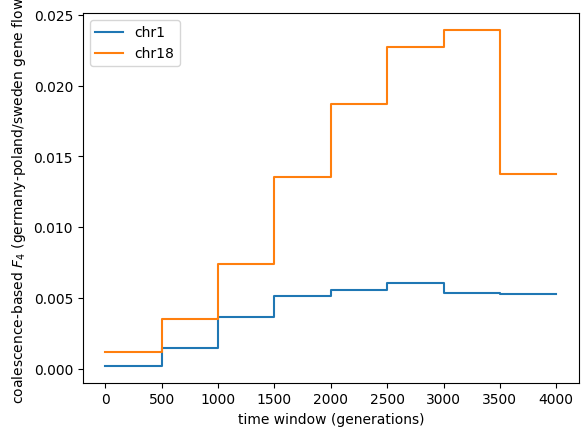

In [104]:
plt.step(tws, -np.append(f4_chr1,f4_chr1[-1]), where="post", label="chr1")
plt.step(tws, -np.append(f4_chr18,f4_chr18[-1]), where="post", label="chr18")
plt.xlabel('time window (generations)')
plt.ylabel('coalescence-based $F_4$ (germany-poland/sweden gene flow)')
# plt.ylim(0,None)
plt.legend()
plt.show()

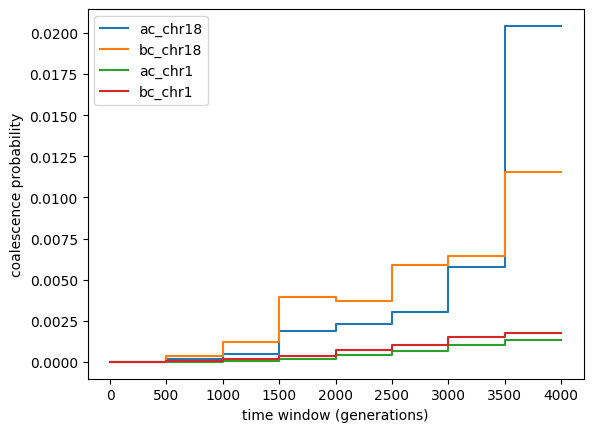

In [99]:
plt.step(tws, np.append(pac_18,pac_18[-1]), where="post", label="ac_chr18")
plt.step(tws, np.append(pbc_18,pbc_18[-1]), where="post", label="bc_chr18")
plt.step(tws, np.append(pac_1,pac_1[-1]), where="post", label="ac_chr1")
plt.step(tws, np.append(pbc_1,pbc_1[-1]), where="post", label="bc_chr1")
plt.xlabel('time window (generations)')
plt.ylabel('coalescence probability')
# plt.ylim(0,None)
plt.legend()
plt.show()

to focus in on barrier region, lets check out fst

In [8]:
fst = []
windows = []
for c in chrmap.keys():
    fst.append(np.load('../data/fst_%s.npy' %chrmap[c]))
    windows.append(np.load('../data/fst_windows_%s.npy' %chrmap[c]))

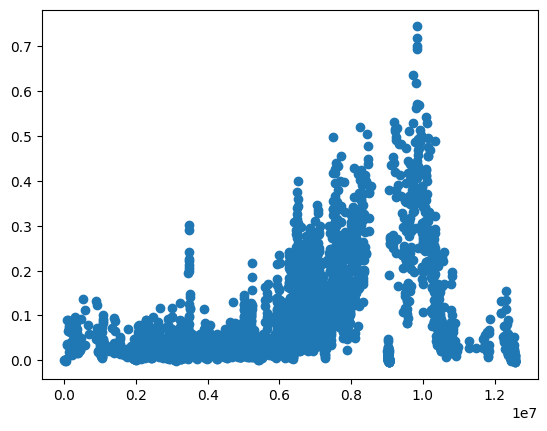

In [18]:
plt.scatter(windows[17][:-1], fst[17])
plt.show()

In [26]:
chrname = 'NC_046347.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)

In [27]:
ts_peak = ts.keep_intervals([[0.8e7,1e7]])
ts_peak

In [28]:
ts_placebo = ts.keep_intervals([[0.325e7,0.4e7]])
ts_placebo

In [29]:
tws = np.linspace(0,4000,9)
tws

array([   0.,  500., 1000., 1500., 2000., 2500., 3000., 3500., 4000.])

In [30]:
cor,cnx = [], []
for i,p in enumerate(poplabels):
    if p[2]=='r':
        cor.append(i)
    elif p[2]=='x':
        cnx.append(i)

In [31]:
chrname = 'NC_046332.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
f2_chr1,paa1,pbb1,pab1 = coalescence_based_f2(ts, [cor,cnx], tws)

In [32]:
chrname = 'NC_046347.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
f2,paa,pbb,pab = coalescence_based_f2(ts, [cor,cnx], tws)

In [33]:
f2_peak,paa_peak,pbb_peak,pab_peak = coalescence_based_f2(ts_peak, [cor,cnx], tws)

In [34]:
f2_placebo,paa_placebo,pbb_placebo,pab_placebo = coalescence_based_f2(ts_placebo, [cor,cnx], tws)

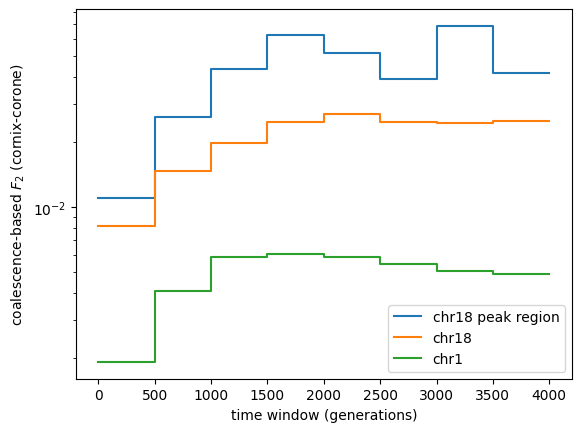

In [50]:
# plt.step(tws, np.append(f2_placebo,f2_placebo[-1]), where="post", label="chr18 placebo")
plt.step(tws, np.append(f2_peak,f2_peak[-1]), where="post", label="chr18 peak region")
plt.step(tws, np.append(f2,f2[-1]), where="post", label="chr18")
plt.step(tws, np.append(f2_chr1,f2_chr1[-1]), where="post", label="chr1")
plt.xlabel('time window (generations)')
plt.ylabel('coalescence-based $F_2$ (cornix-corone)')
# plt.ylim(0,None)
plt.yscale('log')
plt.legend()
plt.show()

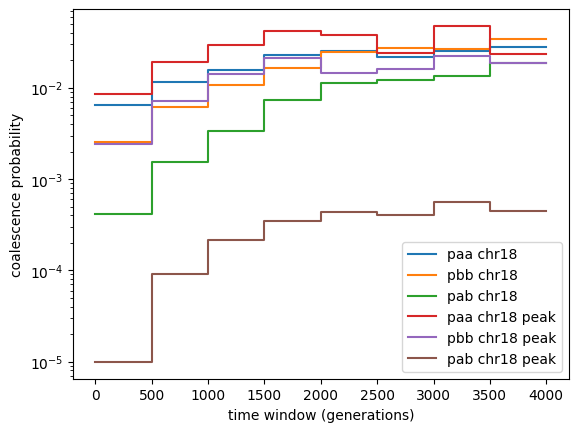

In [49]:
plt.step(tws, np.append(paa,paa[-1]), where="post", label="paa chr18")
plt.step(tws, np.append(pbb,pbb[-1]), where="post", label="pbb chr18")
plt.step(tws, np.append(pab,pab[-1]), where="post", label="pab chr18")
plt.step(tws, np.append(paa_peak,paa_peak[-1]), where="post", label="paa chr18 peak")
plt.step(tws, np.append(pbb_peak,pbb_peak[-1]), where="post", label="pbb chr18 peak")
plt.step(tws, np.append(pab_peak,pab_peak[-1]), where="post", label="pab chr18 peak")
plt.xlabel('time window (generations)')
plt.ylabel('coalescence probability')
plt.yscale('log')
# plt.ylim(0,None)
plt.legend()
plt.show()

check this matches Relate effective sizes

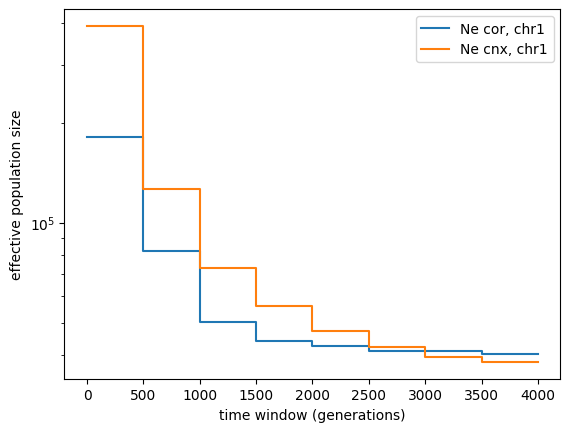

In [55]:
plt.step(tws, 1/(2*np.append(paa1,paa1[-1])/500), where="post", label="Ne cor, chr1")
plt.step(tws, 1/(2*np.append(pbb1,pbb1[-1])/500), where="post", label="Ne cnx, chr1")
plt.xlabel('time window (generations)')
plt.ylabel('effective population size')
plt.yscale('log')
# plt.ylim(0,None)
plt.legend()
plt.show()

In [37]:
irq,cor,cnx = [], [], []
for i,p in enumerate(poplabels):
    if p=='cnx6':
        irq.append(i)
    elif p[2]=='r':
        cor.append(i)
    elif p[2]=='x':
        cnx.append(i)

In [38]:
tws = np.linspace(0,4000,9)
tws

array([   0.,  500., 1000., 1500., 2000., 2500., 3000., 3500., 4000.])

In [39]:
chrname = 'NC_046332.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
f4_chr1, pac_1, pbc_1 = coalescence_based_f4(ts, [irq,cnx,cor], tws)

In [40]:
chrname = 'NC_046347.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
f4_chr18, pac_18, pbc_18 = coalescence_based_f4(ts, [irq,cnx,cor], tws)

In [41]:
f4_peak, pac_peak, pbc_peak = coalescence_based_f4(ts_peak, [irq,cnx,cor], tws)

In [42]:
f4_placebo, pac_placebo, pbc_placebo = coalescence_based_f4(ts_placebo, [irq,cnx,cor], tws)

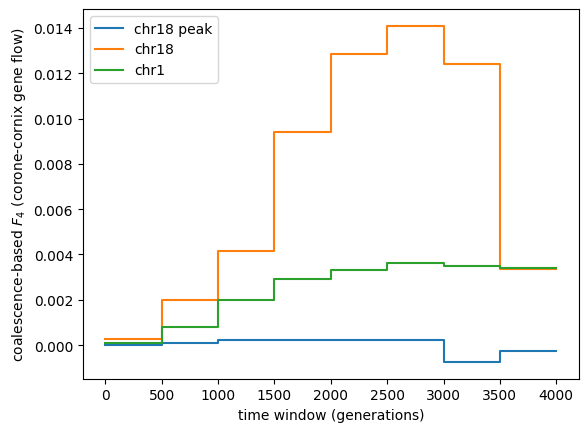

In [43]:
# plt.step(tws, -np.append(f4_placebo,f4_placebo[-1]), where="post", label="chr18 placebo")
plt.step(tws, -np.append(f4_peak,f4_peak[-1]), where="post", label="chr18 peak")
plt.step(tws, -np.append(f4_chr18,f4_chr18[-1]), where="post", label="chr18")
plt.step(tws, -np.append(f4_chr1,f4_chr1[-1]), where="post", label="chr1")
plt.xlabel('time window (generations)')
plt.ylabel('coalescence-based $F_4$ (corone-cornix gene flow)')
# plt.ylim(0,None)
plt.legend()
plt.show()

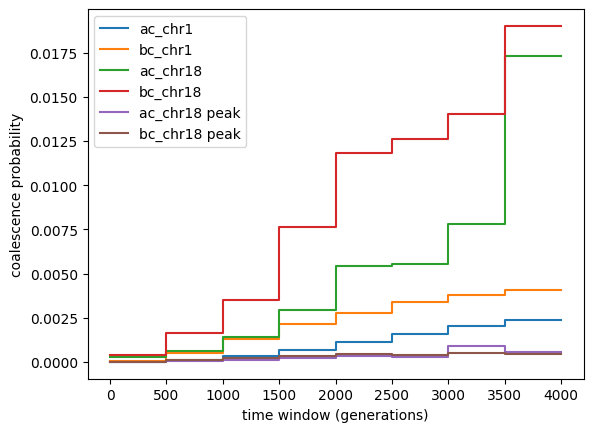

In [44]:
plt.step(tws, np.append(pac_1,pac_1[-1]), where="post", label="ac_chr1")
plt.step(tws, np.append(pbc_1,pbc_1[-1]), where="post", label="bc_chr1")
plt.step(tws, np.append(pac_18,pac_18[-1]), where="post", label="ac_chr18")
plt.step(tws, np.append(pbc_18,pbc_18[-1]), where="post", label="bc_chr18")
plt.step(tws, np.append(pac_peak,pac_peak[-1]), where="post", label="ac_chr18 peak")
plt.step(tws, np.append(pbc_peak,pbc_peak[-1]), where="post", label="bc_chr18 peak")
# plt.step(tws, np.append(pac_placebo,pac_placebo[-1]), where="post", label="ac_chr18 placebo")
# plt.step(tws, np.append(pbc_placebo,pbc_placebo[-1]), where="post", label="bc_chr18 placebo")
plt.xlabel('time window (generations)')
plt.ylabel('coalescence probability')
# plt.ylim(0,None)
plt.legend()
plt.show()

In [81]:
irq,cor,cnx = [], [], []
for i,p in enumerate(poplabels):
    if poplabels[i]=='cnx6':
        irq.append(i)
    elif poplabels[i]=='cor1':
        cor.append(i)
    elif poplabels[i]=='cnx2':
        cnx.append(i)

In [95]:
irq,cor,cnx = [], [], []
for i,p in enumerate(poplabels):
    if p=='cnx6':
        irq.append(i)
    elif p[2]=='r':
        cor.append(i)
    elif p[2]=='x':
        cnx.append(i)

In [96]:
tws = np.linspace(0,10000,11)
tws

array([    0.,  1000.,  2000.,  3000.,  4000.,  5000.,  6000.,  7000.,
        8000.,  9000., 10000.])

In [97]:
chrname = 'NC_046332.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
f4_chr1, pac_1, pbc_1 = coalescence_based_f4(ts, [irq,cnx,cor], tws)

In [98]:
chrname = 'NC_046347.1'
ts = tskit.load('../data/relate_%s_popsize.trees' %chrname)
f4_chr18, pac_18, pbc_18 = coalescence_based_f4(ts, [irq,cnx,cor], tws)

In [99]:
f4_peak, pac_peak, pbc_peak = coalescence_based_f4(ts_peak, [irq,cnx,cor], tws)

In [100]:
f4_placebo, pac_placebo, pbc_placebo = coalescence_based_f4(ts_placebo, [irq,cnx,cor], tws)

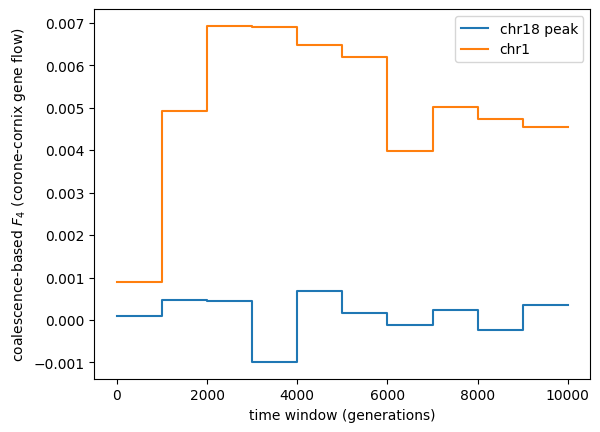

In [103]:
# plt.step(tws, -np.append(f4_placebo,f4_placebo[-1]), where="post", label="chr18 placebo")
plt.step(tws, -np.append(f4_peak,f4_peak[-1]), where="post", label="chr18 peak")
# plt.step(tws, -np.append(f4_chr18,f4_chr18[-1]), where="post", label="chr18")
plt.step(tws, -np.append(f4_chr1,f4_chr1[-1]), where="post", label="chr1")
plt.xlabel('time window (generations)')
plt.ylabel('coalescence-based $F_4$ (corone-cornix gene flow)')
# plt.ylim(0,None)
plt.legend()
plt.show()

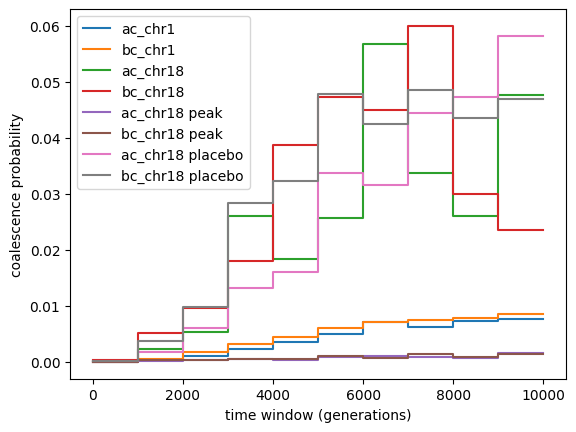

In [88]:
plt.step(tws, np.append(pac_1,pac_1[-1]), where="post", label="ac_chr1")
plt.step(tws, np.append(pbc_1,pbc_1[-1]), where="post", label="bc_chr1")
plt.step(tws, np.append(pac_18,pac_18[-1]), where="post", label="ac_chr18")
plt.step(tws, np.append(pbc_18,pbc_18[-1]), where="post", label="bc_chr18")
plt.step(tws, np.append(pac_peak,pac_peak[-1]), where="post", label="ac_chr18 peak")
plt.step(tws, np.append(pbc_peak,pbc_peak[-1]), where="post", label="bc_chr18 peak")
plt.step(tws, np.append(pac_placebo,pac_placebo[-1]), where="post", label="ac_chr18 placebo")
plt.step(tws, np.append(pbc_placebo,pbc_placebo[-1]), where="post", label="bc_chr18 placebo")
plt.xlabel('time window (generations)')
plt.ylabel('coalescence probability')
# plt.ylim(0,None)
plt.legend()
plt.show()